# Trening głębokiej sieci neuronowej do zadań regresyjnych

W tym skrypcie pokażę na przykładzie danych opisujących rynek mieszkaniowy w USA jak można zbudować głęboką sieć neuronową do szacowania ceny mieszkań. 
Pokażę co należy zrobić przed zaimplementowaniem pierwszych modeli opartych o neurony, na co należy zwracać uwagę podczas pracy na danych (gdyż tym istotnie się zajmujemy, a możliwość prowadzenia prognoz to wisienka na torcie),
jak czytać poszczególne metryki i co może taki analityk danych zrobić, aby prognozy były najbardziej trafne.


In [3]:
!pip install pandas torch numpy scikit-learn statsmodels matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



W pierwszej kolejności należy zainstalować odpowiednie pakiety. Do każdej pracy na danych należy bezwzględnie pobierać:

- pandas (pakiet do zestawów danych różnego rodzaju uporządkowanych w kolumny)
- numpy (pakiet do wykonywania niezbędnych obliczeń)
- sklearn (pakiet scikit-learn, ma wiele wbudowanych prosty modeli uczenia maszynowego, metryki)
- matplotlib (do tworzenia wykresów)

Oprócz tego instaluję torch, statsmodels i seaborn. Pierwszy posłuży do zamodelowania sieci neuronowej (oczywiście można zamiast niego użyć kerasa, nie będę mówić Wam jak żyć :D). Statsmodels umożliwi mi wykonanie pewnych testów statycznych, które będą naprawdę pomocne. A seaborn posłuży mi do tworzenia tzw. heatmap czyli rysunków opisujących natężenie pewnych cech i są o tyle pomocne, bo umożliają mi badanie np. korelacji dwóch zmiennych.

In [4]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("apartments.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("scripts/introduction/apartments.csv")

df = pd.read_csv(DATA_PATH)
print(df.head())
print(df.describe())
print(df.describe(include='object'))

TARGET = 'price'
OUTPUTS_DIR = 'outputs/reg/'


         date      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0  2014-05-02   313000.0       3.0       1.50         1340      7912     1.5   
1  2014-05-02  2384000.0       5.0       2.50         3650      9050     2.0   
2  2014-05-02   342000.0       3.0       2.00         1930     11947     1.0   
3  2014-05-02   420000.0       3.0       2.25         2000      8030     1.0   
4  2014-05-02   550000.0       4.0       2.50         1940     10500     1.0   

   waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0           0     0          3        1340              0      1955   
1           0     4          5        3370            280      1921   
2           0     0          4        1930              0      1966   
3           0     0          4        1000           1000      1963   
4           0     0          4        1140            800      1976   

   yr_renovated                    street       city  statezip  price_per_sqft  
0          

Wczytawszy dane warto zasięgnąć najpierw banalnych statystyk opisowych. Do nich należą: 

- średnia
- odchylenie standardowe
- kwarty
- maksima i minima 
- liczby unikalnych cech zmiennych kategorialnych
- itd.

Pozwalają one zapoznać się wstępnie z ich właściwościami, rzędami wielkości i pozwalają mi wskazać pierwszych kandydatów do usunięcia. W pracy na danych jeżeli są jakieś identyfikatory, to powinny one zniknąć, bo to są zmienne które nie niosą żadnej istotnej informacji. Na pierwszy rzut oka takim kandydatem wygląda zmienna `street`, ponieważ 4.5k różnych parametrów może być problematyczne dla prostego modelu do przyjęcia.

NameError: name 'os' is not defined

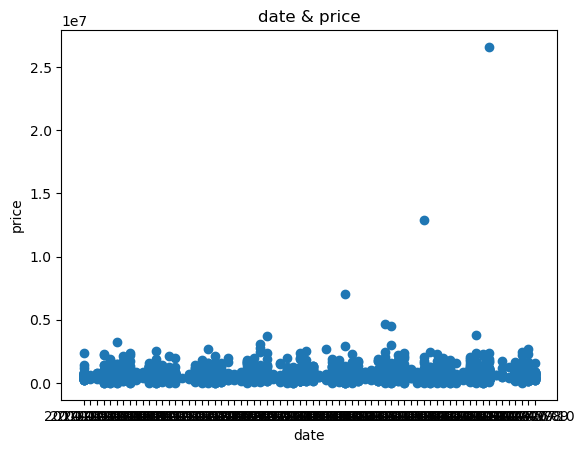

In [ ]:
import matplotlib.pyplot as plt
import os

def plot_scatter_plot(df, x, y):
    plt.scatter(df[x], df[y])
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} & {y}")
    os.makedirs(f"{OUTPUTS_DIR}/scatterplots/", exist_ok=True)
    plt.savefig(f"{OUTPUTS_DIR}/scatterplots/{x} & {y}.png")
    plt.close()

for i in range(len(df.columns)):
    plot_scatter_plot(df, df.columns[i], TARGET)
    # for j in range(i + 1, len(df.columns)):
    #     plot_scatter_plot(df, df.columns[i], df.columns[j])


Tutaj generuję wykresy pokazujące rozkład zmiennych niezależnych od zmiennej zależnej oraz ich rozkłady. Badanie wykresów pozwoli zidentyfikować outliery, czyli obserwacje bardzo odstające od reszty.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import os
import pandas as pd

def get_numeric_columns(df: pd.DataFrame) -> list:
    return df.select_dtypes(include=[np.number]).columns.tolist()

def get_categorical_columns(df: pd.DataFrame) -> list:
    return df.select_dtypes(include=["object", "category"]).columns.tolist()


def encode_categorical(df: pd.DataFrame) -> pd.DataFrame:
    """Koduje zmienne kategorialne na potrzeby szybkiej analizy korelacji."""
    df_encoded = df.copy()
    categorical_cols = get_categorical_columns(df)
    
    for col in categorical_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df[col].astype(str))
    
    return df_encoded


def compute_correlation_matrix(df: pd.DataFrame, method: str = "pearson", include_categorical: bool = True) -> pd.DataFrame:
    """Oblicza macierz korelacji, opcjonalnie z uwzglednieniem zmiennych kategorialnych."""
    if include_categorical:
        df_encoded = encode_categorical(df)
        return df_encoded.corr(method=method)
    else:
        numeric_df = df.select_dtypes(include=[np.number])
        return numeric_df.corr(method=method)


def plot_correlation_matrix(
    corr_matrix: pd.DataFrame,
    output_path: str = f"{OUTPUTS_DIR}/correlation_matrix.png",
    figsize: tuple = (18, 16),
    cmap: str = "coolwarm",
    title: str = "Macierz korelacji wszystkich zmiennych"
):
    plt.figure(figsize=figsize)
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        annot_kws={"size": 7}
    )
    
    plt.title(title, fontsize=16, fontweight="bold")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Macierz korelacji zapisana do: {output_path}")


def get_top_correlations(corr_matrix: pd.DataFrame, n: int = 10) -> pd.DataFrame:
    corr_pairs = corr_matrix.unstack()
    
    corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)]
    
    corr_pairs = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)
    
    top_corr = pd.DataFrame({
        "Zmienna 1": [idx[0] for idx in corr_pairs.head(n).index],
        "Zmienna 2": [idx[1] for idx in corr_pairs.head(n).index],
        "Korelacja": corr_pairs.head(n).values
    })
    
    return top_corr


def filter_prices_and_outliers(df: pd.DataFrame, target_col: str, upper_quantile: float = 0.99) -> pd.DataFrame:
    before = len(df)
    cleaned = df[df[target_col] > 0].copy()
    removed_non_positive = before - len(cleaned)

    upper_price = cleaned[target_col].quantile(upper_quantile)
    cleaned = cleaned[cleaned[target_col] <= upper_price].copy()
    removed_outliers = before - removed_non_positive - len(cleaned)

    print(f"Usunieto ceny <= 0: {removed_non_positive}")
    print(f"Usunieto outliery powyzej {upper_quantile:.0%} percentyla ceny ({upper_price:,.2f}): {removed_outliers}")
    print(f"Pozostalo rekordow: {len(cleaned)} z {before}")
    return cleaned

def getYear(df):
    df['date'] = df['date'].map(lambda date: int(date[:4]))
    return df

corr_matrix = compute_correlation_matrix(df, method="pearson", include_categorical=True)
plot_correlation_matrix(corr_matrix, output_path=f"{OUTPUTS_DIR}/correlation_matrix.png", title="Macierz korelacji wszystkich zmiennych")
print("Top 10 korelacji:")
print(get_top_correlations(corr_matrix, n=10))

df = filter_prices_and_outliers(df, TARGET, upper_quantile=0.99)
df = getYear(df)

# - date wymaga osobnej inzynierii cech,
DROP_COLUMNS = ['street', 'price_per_sqft', 'sqft_above']
df = df.drop(columns=DROP_COLUMNS, errors='ignore')
print(df.head())
print(df[TARGET].describe())


Macierz korelacji zapisana do: outputs/reg//correlation_matrix.png
Top 10 korelacji:
   Zmienna 1    Zmienna 2  Korelacja
0  bathrooms  sqft_living   0.732996
1       city     statezip   0.679919
2      price  sqft_living   0.663028
3   bedrooms  sqft_living   0.594744
4  bathrooms     bedrooms   0.533504
5  bathrooms        price   0.505280
6  bathrooms       floors   0.492413
7  bathrooms     yr_built   0.491275
8     floors     yr_built   0.478566
9  condition     yr_built  -0.398341
Usunieto ceny <= 0: 0
Usunieto outliery powyzej 99% percentyla ceny (1,390,940.00): 45
Pozostalo rekordow: 4414 z 4459


KeyError: 'date'

W tym segmencie tworzę macierz korelacji i dokonuję filtracji rekordów, które mają niedozwolone wartości np. null'e, ceny poniżej zera oraz outliery spoza 99% obserwacji. W tym przypadku usuwam mieszkania, które są albo ruderami, albo luksusowymi apartamentowcami, które nie rządzą się tymi samymi prawami wolnego rynku, co przeciętne mieszkania kawalerskie, domy jedno-, wielorodzinne, itp. Jest to bardzo ważny etap, gdyż takie obserwacje odstające od szeroko przyjętych norm mogą dać modelowi niepotrzebny szum, który będzie istotnie wpływał na prognozy. 

Ważna rzecz do powiedzenia tutaj: jeżeli pracujesz na danych to miej orientację na tym "polu walki" od kogo są te dane, co reprezentują wartości poszczególnych kolumn, czego oczekuje szef lub klient od Ciebie. Świat analizy danych jest całkiem pogmatwany i nietrudno zgubić się w różnych matematycznych wzorach, testach, modelach i trudnych pojęciach, ale na koniec dnia oczekiwania są czysto biznesowe - czy potrafisz oszacować ryzyko, potrzebny nakład pracy lub pieniędzy albo czas.

Po przejrzeniu macierzy korelacji mam kilka zmiennych do usunięcia:

- `street`, gdyż nie niesie żadnej informacji ze sobą, a ponadto wprowadza kilka tysięcy niepotrzebnych cech (duża kardynalność) oraz zmniejsza elastyczność modelu w podobny sposób co zmienna powyżej, tzn. nie daje możliwości wykorzystywania modelu na innych adresach niż podane
- `price_per_sqft`, gdyż jest SILNIE skorelowana ze zmienną `price` (wartość 0.88 - to bardzo dużo) i pozwala ona zgadnąć zmienną `price` przez prostą zależność - im droższy metraż, tym droższe mieszkanie. Celem jest oszacowanie wartości mieszkania na podstawie innych cech, które charakteryzują poszczególne mieszkania
- `sqft_above`, ponieważ jest silnie współliniowe z `sqft_living` i dubluje niepotrzebnie dostarczane informacje

Ogólnie dążmy do tego, by finalny model miał
- możliwie jak najmniej zmiennych wejściowych
- możliwie jak najprostsze wagi (regularyzacja)
- możliwie jak najmniej warstw
- możliwie jak najmniej neuronów
- możliwie jak najlepsze metryki i dopasowanie (ale też bez przesady)

Jak czytać macierz korelacji?
- Wartość bezwzględna poniżej 0.5 - słaba korelacja
- Wartość bezwzględna pomiędzy 0.5, a 0.7 - umiarkowana korelacja
- Wartość bezwzględna powyżej 0.7 - silna korelacja

In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

symbol = '+'

# Q("nazwa_zmiennej") - syntax umożliwiający wprowadzenie wielowyrazowej nazwy kolumny do definicji modelu liniowego
# C(nazwa_zmiennej) - wskazanie, czy dana zmienna jest zmienną kategorialną (jakościową)

categorical_vars = "".join([f'C(Q("{var}")) {symbol} ' for var in get_categorical_columns(df) if var != TARGET])
numeric_vars = "".join([f'{symbol if var != get_numeric_columns(df)[0] else ""} Q("{var}") ' for var in get_numeric_columns(df) if var != TARGET])

definition = f'Q("{TARGET}") ~ ' + categorical_vars + numeric_vars
print(definition)

stats_model = ols(definition, data=df).fit()
anova_result = sm.stats.anova_lm(stats_model, type=2)
print(anova_result)

"""
Wg testu ANOVA wszystkie zmienne są istotne
"""


Tutaj dokonuję dwuczynnikowej analizy wariancji ANOVA z użyciem statystyki F-Snedecora. Są dwie najważniejsze kwestie, na które należy zwracać uwagę podczas czytania tego testu
- Czy wartość testu jest większa od 1?
- Czy p-value jest poniżej 0.05?

Jeżeli p-value jest powyżej 0.05, to oznacza, że ta zmienna jest nieistotna względem zmiennej prognozowanej. Zmienne dodatkowo mogą być istotne, umiarkowanie istotne i bardzo istotne. Jeżeli zmienna ma p-value poniżej 0.01 to jest ona umiarkowanie istotna, a jeżeli poniżej 0.001, to ta zmienna jest bardzo istotna. Zalecam usuwać zmienne najmniej istotne metodą iteracyjną i pojedynczo, ponieważ może się okazać, że któraś zmienna która była nieistotna może okazać się nagle bardzo istotna. Usuwanie zmiennych istotnych, może istotnie pogorszyć zdolności predykcyjne modelu i zmniejszyć dopasowanie modelu do danych.

In [ ]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
import torch

RANDOM_STATE = 42
TEST_SIZE = 0.2
VALID_SIZE = 0.2

def create_preprocessor(df: pd.DataFrame, target_col: str):
    categorical = df.select_dtypes(include=["object", "category"]).columns.tolist()
    categorical = [col for col in categorical if col != target_col]

    numeric = df.select_dtypes(exclude=["object", "category"]).columns.tolist()
    numeric = [col for col in numeric if col != target_col]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
            ("num", StandardScaler(), numeric),
        ]
    )
    return preprocessor

def to_dense_array(matrix):
    return matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)

preprocessor = create_preprocessor(df, TARGET)

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(np.float32)

train_val_x, test_x, train_val_y, test_y = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE,
)
validation_fraction = VALID_SIZE / (1 - TEST_SIZE)
train_x, val_x, train_y, val_y = train_test_split(
    train_val_x,
    train_val_y,
    test_size=validation_fraction,
    random_state=RANDOM_STATE,
)

x_train_np = to_dense_array(preprocessor.fit_transform(train_x)).astype(np.float32)
x_val_np = to_dense_array(preprocessor.transform(val_x)).astype(np.float32)
x_test_np = to_dense_array(preprocessor.transform(test_x)).astype(np.float32)

y_scaler = StandardScaler()
y_train_scaled_np = y_scaler.fit_transform(train_y.to_numpy().reshape(-1, 1)).ravel().astype(np.float32)
y_val_scaled_np = y_scaler.transform(val_y.to_numpy().reshape(-1, 1)).ravel().astype(np.float32)
y_test_scaled_np = y_scaler.transform(test_y.to_numpy().reshape(-1, 1)).ravel().astype(np.float32)

x_train_t = torch.tensor(x_train_np, dtype=torch.float32)
x_val_t = torch.tensor(x_val_np, dtype=torch.float32)
x_test_t = torch.tensor(x_test_np, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled_np, dtype=torch.float32)
y_val_t = torch.tensor(y_val_scaled_np, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled_np, dtype=torch.float32)

y_train_raw = train_y.to_numpy(dtype=np.float32)
y_val_raw = val_y.to_numpy(dtype=np.float32)
y_test_raw = test_y.to_numpy(dtype=np.float32)

print("train:", x_train_t.shape, y_train_t.shape)
print("validation:", x_val_t.shape, y_val_t.shape)
print("test:", x_test_t.shape, y_test_t.shape)


In [ ]:
Powyżej dokonuję ostatnich preprocessingowych czynności, mianowicie transformacji zmiennych. Standaryzuję zmienne ilościowe i hardkoduję zmienne jakościowe. Standaryzacja polega na tym, że rzutuję wartości danej zmiennej na rozkład normalny z wartością oczekiwaną równą 0 i odchyleniem standardowym równym 1. Zaś przez hardkodowanie mam na myśli rzutowanie zmiennych kategorialnych na wektory zer i jedynek reprezentujących występowanie poszczególnych cech tych zmiennych. Jest to jeden ze sposobów na radzenie sobie z takimi zmiennymi. Jeżeli natura takie zmiennej jest porządkowa, tzn. jedna cecha jest wyżej ceniona od drugiej, to można rzutować je na liczby o większym zakresie i nie trzeba posługiwać się wektorami do ich zapisu.

Oprócz tego dzielę zbiór danych na osobne podzbiory: treningowy, walidacyjny i testowy.

Następnie dokonuję transformacji zmiennych do postaci przyjmowalnej przez model sieci neuronowej - tensory. Tensor jest abstrakcyjnym bytem matematycznym łączącym ze sobą skalary, wektory, macierze, itd. Zaś tutaj jest formatem danych, który uogólnia reprezentowanie liczb zarówno na kartach graficznych (i optymalizuje obliczenia), jak i na procesorach. 

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.stattools import durbin_watson

def adjusted_r2_score(y_true, y_pred, n_features):
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    if n <= n_features + 1:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

def information_criteria(y_true, y_pred, n_params):
    residuals = np.asarray(y_true) - np.asarray(y_pred)
    n = residuals.size
    rss = np.sum(residuals ** 2)
    mse = max(rss / n, np.finfo(float).eps)

    # Gaussian-residual approximation. For neural networks this is useful mostly for rough comparison.
    aic = n * np.log(mse) + 2 * n_params
    bic = n * np.log(mse) + np.log(n) * n_params
    return aic, bic

def theil_u_decomposition(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    errors = y_pred - y_true
    mse = np.mean(errors ** 2)

    denominator = np.sqrt(np.mean(y_pred ** 2)) + np.sqrt(np.mean(y_true ** 2))
    theil_u = np.sqrt(mse) / denominator if denominator > 0 else np.nan

    if mse <= np.finfo(float).eps:
        return {
            "Theil_U": theil_u,
            "Theil_bias_proportion": 0.0,
            "Theil_variance_proportion": 0.0,
            "Theil_covariance_proportion": 0.0,
        }

    pred_mean = np.mean(y_pred)
    true_mean = np.mean(y_true)
    pred_std = np.std(y_pred, ddof=0)
    true_std = np.std(y_true, ddof=0)

    if pred_std <= np.finfo(float).eps or true_std <= np.finfo(float).eps:
        corr = 0.0
    else:
        corr = np.corrcoef(y_pred, y_true)[0, 1]

    bias_proportion = (pred_mean - true_mean) ** 2 / mse
    variance_proportion = (pred_std - true_std) ** 2 / mse
    covariance_proportion = 2 * pred_std * true_std * (1 - corr) / mse

    return {
        "Theil_U": theil_u,
        "Theil_bias_proportion": bias_proportion,
        "Theil_variance_proportion": variance_proportion,
        "Theil_covariance_proportion": covariance_proportion,
    }

def interpret_durbin_watson(dw_value):
    if np.isnan(dw_value):
        return "brak interpretacji"
    if dw_value < 1.5:
        return "dodatnia autokorelacja reszt"
    if dw_value <= 2.5:
        return "brak wyraznej autokorelacji reszt"
    return "ujemna autokorelacja reszt"

def residual_autocorrelation_tests(residuals):
    residuals = np.asarray(residuals, dtype=float)
    dw_value = durbin_watson(residuals)
    return {
        "Durbin_Watson": dw_value,
        "Durbin_Watson_interpretation": interpret_durbin_watson(dw_value),
    }

def calculate_regression_diagnostics(y_true, y_pred, n_features, n_params, label="Model"):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residuals = y_true - y_pred
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    aic, bic = information_criteria(y_true, y_pred, n_params=n_params)

    metrics = {
        "model": label,
        "n_observations": len(y_true),
        "n_features": n_features,
        "n_params": n_params,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
        "Adjusted_R2": adjusted_r2_score(y_true, y_pred, n_features=n_features),
        "AIC": aic,
        "BIC": bic,
    }
    metrics.update(residual_autocorrelation_tests(residuals))
    metrics.update(theil_u_decomposition(y_true, y_pred))
    return metrics

def print_metrics(metrics):
    print(f"{metrics['model']} diagnostics")
    for key, value in metrics.items():
        if key == "model":
            continue
        if isinstance(value, str):
            print(f"{key}: {value}")
        elif isinstance(value, (int, np.integer)):
            print(f"{key}: {value}")
        else:
            print(f"{key}: {value:,.6f}")

def count_trainable_parameters(model):
    return sum(param.numel() for param in model.parameters() if param.requires_grad)

def plot_training(history, output_path):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    epochs = [row["epoch"] for row in history]
    train_loss = [row["train_loss"] for row in history]
    val_loss = [row.get("val_loss") for row in history]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(epochs, train_loss, label="train loss", linewidth=2)

    if any(loss is not None for loss in val_loss):
        ax.plot(epochs, val_loss, label="validation loss", linewidth=2)

    ax.set(xlabel="epoch", ylabel="MSE loss")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(f"{output_path}_training.png")
    plt.close()

def plot_predictions(y_true, y_pred, output_path):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, alpha=0.45)

    min_value = min(y_true.min(), y_pred.min())
    max_value = max(y_true.max(), y_pred.max())
    ax.plot([min_value, max_value], [min_value, max_value], color="crimson", linestyle="--")

    ax.set(xlabel="Actual price", ylabel="Predicted price", title="Predictions vs actual values")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(f"{output_path}_predictions.png")
    plt.close()

def plot_residuals(y_true, y_pred, output_path):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    residuals = y_true - y_pred

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(y_pred, residuals, alpha=0.45)
    ax.axhline(0, color="crimson", linestyle="--")
    ax.set(xlabel="Predicted price", ylabel="Residual", title="Residual plot")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(f"{output_path}_residuals.png")
    plt.close()


Powyżej zdefiniowałem kilka funkcji obliczających pewne metryki, które będą niezbędne do ocenienia modelu regresji.

## Ex-ante

### Współczynnik $R^2$
Określa on miarę dopasowania predykcji do prawdziwych obserwacji na podstawie wariancji.

### Skorygowany współczynnik $R^2$
Jest to współczynnik, który uwzględnia dodatkowo liczbę zmiennych wejściowych modelu prognostycznego. Pozwala on porównywać ze sobą modele o różnej liczbie parametrów.

### Kryterium informacyjne
Ta miara określa, jak bardzo złożony jest to model. Bierze pod uwagę liczbę zmiennych, wielkość wag. Im mniejsza ta miara, tym model prostszy.

### Współczynnik Durbina-Watsona
Określa on, czy reszty predykcji modelu są ze sobą skorelowane, tzn. czy nie zachodzi autokorelacja reszt, która zaburza zdolność predykcyjną modelu.

## Ex-post

### Współczynnik U-Theila
Zwraca informację o tym, jak trafne są prognozy modelu i oblicza się go ex post (po zbudowaniu modelu na danych testowych). Wartość 0 oznacza idealne prognozy (nieosiągalne), 1 oznacza porównywalną zdolność do zgadywania, a powyżej 1 gorszą od zgadywania. Dodatkowo w ramach tego współczynnika bierze się pod uwagę 3 składniki:
- udział obciążenia (błąd średniej tzw. bias) - różnica między średnią prognoz, a średnią wartości rzeczywistych. Dążymy do wartości 0
- udział niedostatecznej elastyczności (błąd wariancji) - różnica odchylenia stand. prognoz i wartości rzeczywistych. Dążymy do wartości 0
- udział niezgodności kierunku zmian (błąd kowariancji reszt) - miara korelacji między prognozami, a wartościami rzeczywistymi. Dążymy do wartości 1
Wszystkie wartości powyższych faktorów odzwierciedlają procentowy udział we współczynniku U-Theila.




In [ ]:
from sklearn.linear_model import LinearRegression

baseline_model = LinearRegression()
baseline_model.fit(x_train_np, y_train_raw)
y_pred_baseline = baseline_model.predict(x_test_np)

baseline_metrics = calculate_regression_diagnostics(
    y_true=y_test_raw,
    y_pred=y_pred_baseline,
    n_features=x_test_np.shape[1],
    n_params=x_test_np.shape[1] + 1,
    label="Linear Regression",
)
print_metrics(baseline_metrics)


Bardzo ważne jest, aby przed projektowaniem jakiegoś docelowego modelu stworzyć jakiś bardzo prosty baseline, czyli punkt odniesienia który pozwoli stwierdzić, czy ostateczny model jest lepszy, a może gorszy od prostego modelu. 
Jak widać po statystykach tego modelu, nie będzie to trudne. 

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

def create_data_loader(x_t, y_t, batch_size=128, shuffle=True, seed=RANDOM_STATE):
    dataset = TensorDataset(x_t, y_t)
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator if shuffle else None,
        drop_last=False,
    )

def l1_penalty(model):
    return sum(param.abs().sum() for param in model.parameters())

def train_model(model, train_loader, val_data=None, epochs=200, lr=0.001,
                weight_decay=1e-5, logging_step=10, l1_param=0,
                output_path=f"{OUTPUTS_DIR}/mini-batch"):
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        total = 0

        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()

            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            total_loss = loss + l1_param * l1_penalty(model)

            total_loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * batch_y.size(0)
            total += batch_y.size(0)

        avg_train_loss = epoch_loss / total
        val_loss = None

        if val_data is not None:
            model.eval()
            x_val, y_val = val_data
            with torch.no_grad():
                val_loss = criterion(model(x_val), y_val).item()

        if logging_step != -1 and (epoch == 1 or epoch % logging_step == 0 or epoch == epochs):
            row = {"epoch": epoch, "train_loss": avg_train_loss, "val_loss": val_loss}
            history.append(row)
            message = f"Epoch [{epoch}/{epochs}], train MSE: {avg_train_loss:.4f}"
            if val_loss is not None:
                message += f", val MSE: {val_loss:.4f}"
            print(message)
            plot_training(history, output_path)

    return history

def train_model_full_batch(model, x_train_t, y_train_t, **kwargs):
    loader = create_data_loader(x_train_t, y_train_t, batch_size=len(y_train_t), shuffle=False)
    return train_model(model, loader, **kwargs)

def train_model_mini_batch(model, x_train_t, y_train_t, batch_size=128, **kwargs):
    loader = create_data_loader(x_train_t, y_train_t, batch_size=batch_size, shuffle=True)
    return train_model(model, loader, **kwargs)

def predict_prices(model, x_t, y_scaler):
    model.eval()
    with torch.no_grad():
        preds_scaled = model(x_t).cpu().numpy().reshape(-1, 1)
    return y_scaler.inverse_transform(preds_scaled).ravel()

def evaluate_model(model, x_test_t, y_test_raw, y_scaler, output_path, log=True):
    y_pred = predict_prices(model, x_test_t, y_scaler)
    metrics = calculate_regression_diagnostics(
        y_true=y_test_raw,
        y_pred=y_pred,
        n_features=x_test_t.shape[1],
        n_params=count_trainable_parameters(model),
        label=model.__class__.__name__,
    )

    if log:
        print_metrics(metrics)
        plot_predictions(y_test_raw, y_pred, output_path)
        plot_residuals(y_test_raw, y_pred, output_path)

    return metrics


Trening polega na wielokrotnym korygowaniu wag na podstawie błędów, jakie model popełnia. W tym przypadku miarę błędu oddaje wariancja prognoz względem wartości rzeczywistych. Za pomocą algorytmu backpropagation można obliczać korekty wag od końca, do początku sieci neuronowej, dzięki czemu cały model się poprawia. Trening podzielony jest na epoki, czyli pojedyncze iteracje wykonywane na całości zbioru treningowego. Różnica w podejściach zaczyna się w sposobie iterowania po zbiorze. Można albo cały zbiór treningowy przetworzyć za jednym razem (full-batch), albo fragmentami o równej wielkości, któych kolejność jest losowana w każdej epoce (mini-batch). Więcej o tym piszę w dodatku. 

In [ ]:
from datetime import datetime
import torch.nn as nn

class DeepNet(nn.Module):
    def __init__(self, input: int, hidden_layer: int = 128, dropout=0.0):
        super(DeepNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input, hidden_layer),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_layer, hidden_layer // 2),
            nn.ReLU(),
            nn.Linear(hidden_layer // 2, 1),
        )
        
    def forward(self, x):
        return self.net(x).squeeze(dim=-1)


Tutaj zdefiniowałem prostą sieć neuronową składającą się z czterech warstw: wejściowej, dwóch ukrytych i ostatniej wyjściowej liczącej jeden neuron. Pierwsza ukryta warstwa ma dwa razy więcej neuronów od drugiej. Dodatkowo, po pierwszej ukrytej warstwie stosuję tzw. dropout czyli regularyzację polegającą na losowym zerowaniu wag pomiędzy neuronami. Prawdopodobieństwo usunięcia danego połączenia ustalam zmienną `dropout`. Po każdej warstwie (z wyjątkiem warstwy wyjściowej) stosuję również ReLU, która pozwala zaadaptować nieliniowe właściwości predykcyjne.

In [ ]:
torch.manual_seed(RANDOM_STATE)

full_batch_model = DeepNet(
    input=x_train_t.shape[1],
    hidden_layer=128,
    dropout=0.2,
)
mini_batch_model = DeepNet(
    input=x_train_t.shape[1],
    hidden_layer=128,
    dropout=0.2,
)

timestamp = datetime.now().strftime("%H-%M-%S")
full_batch_output_path = f"{OUTPUTS_DIR}/{timestamp}-full-batch"
mini_batch_output_path = f"{OUTPUTS_DIR}/{timestamp}-mini-batch"

full_batch_loader = create_data_loader(
    x_train_t,
    y_train_t,
    batch_size=len(y_train_t),
    shuffle=False,
)
mini_batch_loader = create_data_loader(
    x_train_t,
    y_train_t,
    batch_size=128,
    shuffle=True,
)

mini_batch_history = train_model(
    mini_batch_model,
    mini_batch_loader,
    epochs=10,
    lr=0.001,
    weight_decay=1e-5,
    logging_step=10,
    l1_param=0,
    val_data=(x_val_t, y_val_t),
    output_path=mini_batch_output_path,
)
full_batch_history = train_model(
    full_batch_model,
    full_batch_loader,
    epochs=60,
    lr=0.001,
    weight_decay=1e-5,
    logging_step=10,
    l1_param=0,
    val_data=(x_val_t, y_val_t),
    output_path=full_batch_output_path,
)

print("Full-batch test evaluation")
full_batch_metrics = evaluate_model(
    full_batch_model,
    x_test_t,
    y_test_raw,
    y_scaler,
    full_batch_output_path,
)

print("Mini-batch test evaluation")
mini_batch_metrics = evaluate_model(
    mini_batch_model,
    x_test_t,
    y_test_raw,
    y_scaler,
    mini_batch_output_path,
)

print("Full-batch metrics:", full_batch_metrics)
print("Mini-batch metrics:", mini_batch_metrics)


Wyniki powyższych treningów są bezdyskusyjne. Podejście mini-batch nie tylko pozwala ograniczyć liczbę epok ponad sześciokrotnie, ale również pozwala na lepsze dopasowanie do danych treningowych. Model zbudowany za pomocą mini-batch zwraca predykcje lepiej skorelowane z wartościami rzeczywistymi (współczynnik U-Theila), cechuje się lepszym dopasowaniem (skorygowany współczynnik $R^2$)

In [ ]:
class DeeperNet(nn.Module):
    def __init__(self, input: int, hidden_layer: int = 256, count_of_layers=3, dropout=0.1):
        super(DeeperNet, self).__init__()
        layers = [nn.Linear(input, hidden_layer), nn.ReLU(), nn.Dropout(dropout)]
        for _ in range(count_of_layers - 1):
            layers.extend([nn.Linear(hidden_layer, hidden_layer), nn.ReLU(), nn.Dropout(dropout)])
        layers.append(nn.Linear(hidden_layer, 1))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x).squeeze(dim=-1)

output_path = f"{OUTPUTS_DIR}/{datetime.now().strftime('%H-%M-%S')}-deepernet"
print(output_path)

deepernet = DeeperNet(x_train_t.shape[1], hidden_layer=256, count_of_layers=4, dropout=0.1)
deep_history = train_model_mini_batch(
    deepernet,
    x_train_t,
    y_train_t,
    epochs=100,
    batch_size=128,
    lr=0.001,
    weight_decay=1e-5,
    logging_step=10,
    output_path=output_path,
    val_data=(x_val_t, y_val_t),
)
deep_metrics = evaluate_model(deepernet, x_test_t, y_test_raw, y_scaler, output_path)
print(deep_metrics)


In [ ]:
try:
    import optuna
except ImportError:
    optuna = None

if optuna is None:
    print("Optuna is not installed. Run `pip install optuna` to use this optional tuning cell.")
else:
    optuna_output_path = f"{OUTPUTS_DIR}/{datetime.now().strftime('%H-%M-%S')}-optuna"

    def objective(trial):
        hidden_size = trial.suggest_int("hidden_size", 32, 512)
        dropout = trial.suggest_float("dropout", 0.0, 0.5)
        lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
        batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])

        model = DeepNet(x_train_t.shape[1], hidden_layer=hidden_size, dropout=dropout)
        train_model_mini_batch(
            model,
            x_train_t,
            y_train_t,
            epochs=50,
            batch_size=batch_size,
            lr=lr,
            l1_param=0,
            logging_step=-1,
            val_data=(x_val_t, y_val_t),
        )
        metrics = evaluate_model(model, x_val_t, y_val_raw, y_scaler, optuna_output_path, log=False)
        return metrics["R2"]

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=30)
    print(study.best_params)
